A manufacturing company produces 12 industrial products using four limited production resources: CNC, Assembly, Testing and Packaging. The objective is to determine the optimal production quantities that maximise total profit while respecting machine capacities and market demand.

In [4]:
import pandas as pd
P=pd.read_excel("Data .xlsx")
P


,Product,Profit (€ / Unit),CNC Hours / Unit,Assembly Hours / Unit,Testing Hours / Unit,Packaging Hours / Unit,Maximum Demand
0,Electric Motor,450,8,6,3,1,500
1,Gearbox,380,6,5,2,1,600
2,Industrial Pump,520,9,7,4,2,400
3,Hydraulic Valve,180,3,2,1,1,1200
4,Bearing Unit,150,2,2,1,1,1500
5,Control Panel,320,4,5,3,1,700
6,Conveyor Module,280,5,4,2,1,800
7,Drive Shaft,240,4,3,2,1,1000
8,Brake System,350,5,5,3,1,650
9,Compressor Unit,480,7,6,4,2,450


In [24]:
import pyomo.environ as pyo
model=pyo.ConcreteModel()

#Sets
model.P=pyo.Set(initialize=P["Product"].tolist())
print(list(model.P))
P.columns=P.columns.str.strip()
P.head(1)

['Electric Motor', 'Gearbox', 'Industrial Pump', 'Hydraulic Valve', 'Bearing Unit', 'Control Panel', 'Conveyor Module', 'Drive Shaft', 'Brake System', 'Compressor Unit', 'Robotic Arm', 'Power Converter']


,Product,Profit (€ / Unit),CNC Hours / Unit,Assembly Hours / Unit,Testing Hours / Unit,Packaging Hours / Unit,Maximum Demand
0,Electric Motor,450,8,6,3,1,500


In [ ]:
#Parameters
model.Profit=pyo.Param(model.P,initialize=P.set_index("Product")["Profit (€ / Unit)"].to_dict())
model.CNC_Hours=pyo.Param(model.P,initialize=P.set_index("Product")["CNC Hours / Unit"].to_dict())
model.Assembly_Hours=pyo.Param(model.P,initialize=P.set_index("Product")["Assembly Hours / Unit"].to_dict())
model.Testing_Hours=pyo.Param(model.P,initialize=P.set_index("Product")["Testing Hours / Unit"].to_dict())
model.Packing_Hours=pyo.Param(model.P,initialize=P.set_index("Product")["Packaging Hours / Unit"].to_dict())
model.Maximum_Demand=pyo.Param(model.P,initialize=P.set_index("Product")["Maximum Demand"].to_dict())
model.CNC_capacity = pyo.Param(initialize=25000)
model.Assembly_capacity = pyo.Param(initialize=20000)
model.Testing_capacity = pyo.Param(initialize=12000)
model.Packaging_capacity = pyo.Param(initialize=8000)

In [ ]:
from pyomo.core.base.objective import maximize
model.x=pyo.Var(model.P,within=pyo.NonNegativeReals)
#Objective Function
def Objective_rule(model):
    return sum(model.x[p] * model.Profit[p] for p in model.P)

model.Objective = pyo.Objective(rule=Objective_rule,sense=pyo.maximize)

#Constraints
def CNC_rule(model):
    return sum(model.x[p] * model.CNC_Hours[p] for p in model.P) <= 25000

model.CNC_constraint = pyo.Constraint(rule=CNC_rule)

def Assembly_rule(model):
    return sum(model.x[p] * model.Assembly_Hours[p] for p in model.P) <= 20000

model.Assembly_constraint = pyo.Constraint(rule=Assembly_rule)

def Testing_rule(model):
    return sum(model.x[p] * model.Testing_Hours[p] for p in model.P) <= 12000
def Packaging_rule(model):
    return sum(model.x[p] * model.Packing_Hours[p] for p in model.P) <= 8000

model.Packaging_constraint = pyo.Constraint(rule=Packaging_rule)
def Demand_rule(model, p):
    return model.x[p] <= model.Maximum_Demand[p]

model.Demand_constraint = pyo.Constraint(model.P,rule=Demand_rule)

Decision variable
$$ x_p = \text{number of units of product }p\text{ produced} $$
Objective
$$ \max Z = \sum_{p\in P} Profit_p x_p $$
Machine constraints

For each machine \(m\):

$$ \sum_{p\in P} Hours_{pm}x_p \leq Capacity_m $$
Demand constraints
$$ x_p \leq Demand_p $$
Non-negativity
x
p
	​

≥0

In [ ]:
!apt-get update -qq
!apt-get install -y -qq glpk-utils

In [62]:
import pyomo.environ as pyo

solver = pyo.SolverFactory("glpk")

print("GLPK available:", solver.available())

GLPK available: True


In [63]:
results = solver.solve(model, tee=True)

print("Status:", results.solver.status)
print("Termination:", results.solver.termination_condition)

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /tmp/tmpw54uq3qc.glpk.raw --wglp /tmp/tmpzy8144ct.glpk.glp --cpxlp
 /tmp/tmpf3nvslcc.pyomo.lp
Reading problem data from '/tmp/tmpf3nvslcc.pyomo.lp'...
16 rows, 24 columns, 60 non-zeros
153 lines were read
Writing problem data to '/tmp/tmpzy8144ct.glpk.glp'...
131 lines were written
GLPK Simplex Optimizer 5.0
16 rows, 24 columns, 60 non-zeros
Preprocessing...
4 rows, 24 columns, 48 non-zeros
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.200e+01  ratio =  1.200e+01
GM: min|aij| =  7.071e-01  max|aij| =  1.414e+00  ratio =  2.000e+00
EQ: min|aij| =  5.000e-01  max|aij| =  1.000e+00  ratio =  2.000e+00
Constructing initial basis...
Size of triangular part is 4
*     0: obj =  -0.000000000e+00 inf =   0.000e+00 (12)
*    12: obj =   1.618750000e+06 inf =   0.000e+00 (0)
OPTIMAL LP SOLUTION FOUND
Time used:   0.0 secs
Memory used: 0.0 Mb (50827 bytes)
Writing basic solution to '/tmp/tmpw54uq3qc.glpk.raw

OPTIMAL RESULT:
Electric Motor 450.000000000001
Gearbox 600.0
Industrial Pump 0.0
Hydraulic Valve 1200.0
Bearing Unit 624.999999999996
Control Panel 0.0
Conveyor Module 0.0
Drive Shaft 1000.0
Brake System 0.0
Compressor Unit 450.0
Robotic Arm 250.0
Power Converter 350.0


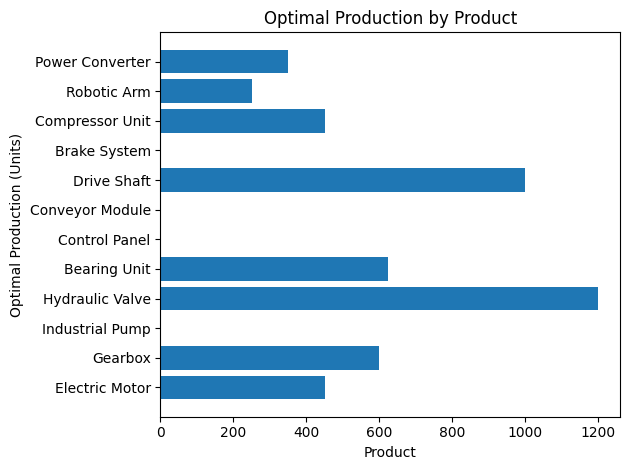

In [76]:
print("OPTIMAL RESULT:")

for p in model.P:
    print(p, pyo.value(model.x[p]))

import matplotlib.pyplot as plt
x=list(model.P)
y=[pyo.value(model.x[p]) for p in model.P]
plt.barh(x,y)
plt.xlabel("Product")
plt.ylabel("Optimal Production (Units)")
plt.title("Optimal Production by Product")

plt.tight_layout()
plt.show()

In [90]:
production_data = []

for p in model.P:
    production_data.append({
        "Product": p,
        "Production": pyo.value(model.x[p]),
        "Maximum Demand": pyo.value(model.Maximum_Demand[p]),
        "Profit per Unit": pyo.value(model.Profit[p])
    })

df_production = pd.DataFrame(production_data)

df_production
df_production.style \
    .background_gradient(
        subset=["Production"]
    ) \
    .format({
        "Production": "{:,.2f}",
        "Maximum Demand": "{:,.0f}",
        "Profit per Unit": "€{:,.0f}"
    })

,Product,Production,Maximum Demand,Profit per Unit
0,Electric Motor,450.00,500,€450
1,Gearbox,600.00,600,€380
2,Industrial Pump,0.00,400,€520
3,Hydraulic Valve,"1,200.00","1,200",€180
4,Bearing Unit,625.00,"1,500",€150
5,Control Panel,0.00,700,€320
6,Conveyor Module,0.00,800,€280
7,Drive Shaft,"1,000.00","1,000",€240
8,Brake System,0.00,650,€350
9,Compressor Unit,450.00,450,€480


In [94]:
print("Maximum Profit:",pyo.value(model.Objective))

Maximum Profit: 1618749.9999999998


In [ ]:
# Compute actual machine hours used at the optimal solution
CNC_used = sum(pyo.value(model.x[p]) * pyo.value(model.CNC_Hours[p]) for p in model.P)
Assembly_used = sum(pyo.value(model.x[p]) * pyo.value(model.Assembly_Hours[p]) for p in model.P)
Testing_used = sum(pyo.value(model.x[p]) * pyo.value(model.Testing_Hours[p]) for p in model.P)
Packaging_used = sum(pyo.value(model.x[p]) * pyo.value(model.Packing_Hours[p]) for p in model.P)

print("CNC hours used:", CNC_used)
print("Assembly hours used:", Assembly_used)
print("Testing hours used:", Testing_used)
print("Packaging hours used:", Packaging_used)

In [96]:
import pandas as pd

machine_data = {
    "Machine": ["CNC", "Assembly", "Testing", "Packaging"],
    "Capacity": [25000, 20000, 12000, 8000],
    "Hours Used": [CNC_used,Assembly_used,Testing_used,Packaging_used]
}

df_machine = pd.DataFrame(machine_data)
df_machine["Unused Capacity"] = (df_machine["Capacity"] - df_machine["Hours Used"])

df_machine["Utilisation (%)"] = ( df_machine["Hours Used"] / df_machine["Capacity"] * 100)

df_machine.style \
    .background_gradient(
        subset=["Utilisation (%)"]
    ) \
    .highlight_max(
        subset=["Utilisation (%)"],
        color="green"
    ) \
    .format({
        "Capacity": "{:,.0f}",
        "Hours Used": "{:,.2f}",
        "Unused Capacity": "{:,.2f}",
        "Utilisation (%)": "{:.2f}%"
    })

,Machine,Capacity,Hours Used,Unused Capacity,Utilisation (%)
0,CNC,"25,000","25,000.00",0.00,100.00%
1,Assembly,"20,000","20,000.00",0.00,100.00%
2,Testing,"12,000","11,425.00",575.00,95.21%
3,Packaging,"8,000","5,975.00","2,025.00",74.69%


In [92]:
bottleneck = df_machine.loc[
    df_machine["Utilisation (%)"].idxmax(),
    "Machine"
]

bottleneck_utilisation = df_machine[
    "Utilisation (%)"
].max()

print("Bottleneck machine:", bottleneck)
print(
    f"Bottleneck utilisation: "
    f"{bottleneck_utilisation:.2f}%"
)

Bottleneck machine: CNC
Bottleneck utilisation: 100.00%


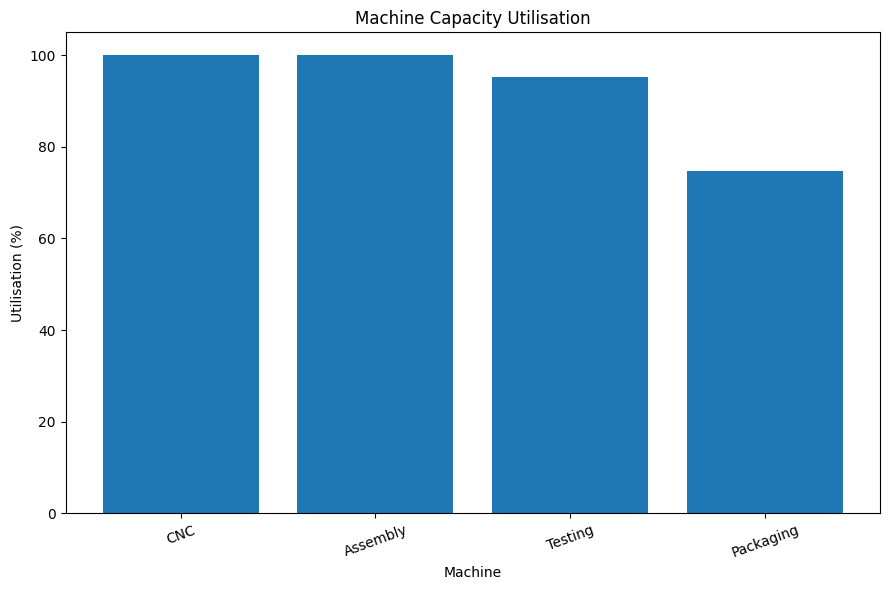

In [93]:
plt.figure(figsize=(9, 6))

plt.bar(
    df_machine["Machine"],
    df_machine["Utilisation (%)"]
)

plt.xlabel("Machine")
plt.ylabel("Utilisation (%)")
plt.title("Machine Capacity Utilisation")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "machine_utilisation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Final Results

The optimisation model determines the production quantities that
maximise total profit while respecting machine capacity and market
demand constraints.

The analysis reports:

- Optimal production quantity for each product
- Maximum total profit
- Machine hours used
- Unused machine capacity
- Machine utilisation
- Bottleneck machine

The bottleneck is identified as the machine with the highest
capacity utilisation.